In [1]:
#Putting the source and shield code into one Python file
%matplotlib ipympl
import numpy as np
import decimal
import matplotlib.pyplot as plt
import scipy as sci
from decimal import Decimal as dec
import ipywidgets as widgets

from matplotlib.colors import LightSource
from matplotlib import cm
import matplotlib as mpl
#All units are SI
#Shielding function adapted from the tutorial on Medium by Vipran Vasan

In [2]:
#This is a dictionary of the densities and mu values for different shielding materials
materials = {
    "Lead": {"density": 11.35, "mu": 0.5},
    "Aluminium" : {"density": 2.7, "mu": 0.136},
    "Steel": {"density": 7.85, "mu": 0.15},
    "Concrete": {"density": 2.4, "mu": 0.03},
    "Tungsten": {"density": 19.254, "mu": 0.5} #I'm not sure where Vasan
    #got their values for mu from so I have given tungsten the same value as 
    #lead until I find it
}

#This is a dictionary of the energies for different sources measured in MeV
sources = {
    "Tc-99m": {"energy": 0.140},
    "Cs-137": {"energy": 0.662},
    "Ir-192": {"energy": 0.617}
}

sources_arr = [('Tc-99m','Tc-99m'),('Cs-137','Cs-137'),('Ir-192','Ir-192')]

resolution_arr = [('m',100),('cm',1000),('mm',10000),('x10^-1mm',100000),('x10^-2mm',1000000),('um',10000000)]

results = {material: 0 for material in materials.keys()}

In [3]:
#This is the class for Radioactive Source, written primarily by Joshua Hanrahan
class RadioactiveObject:

    _shape_aliases = {
        "puck": "puck",
        "pill": "puck",
        "cylinder": "puck",

        "block": "block",
        "cuboid": "block",
        "box": "block",
        "brick": "block"
    }

    def __init__(self, shape, source, **kwargs):
        shape = shape.strip().lower()

        if shape not in self._shape_aliases:
            raise ValueError(f"Unknown shape '{shape}'")

        self.shape = self._shape_aliases[shape]#allows different inputs, for example josh says "puck", kwaku says "pill"
        self.params = kwargs
        #kwargs makes it so that arguments are sorted by keyword rather than index i.e examplePuck = RadiativeObject("pill", depth=5, radius=1) or examplePuck = RadiativeObject("pill", radius=1, depth=5) both work
        self.no = self.params.get("num_particles")
        self.source = sources[source]
        self.energy = self.source["energy"]
        self.loc = self.params.get("location")
        self.x = self.loc[0]
        self.y = self.loc[1]

    def volume(self):
        if self.shape == "puck":
            self.r = self.params.get("radius")
            self.h = self.params.get("height")
            if self.r is None or self.h is None:
                raise ValueError("Puck requires 'radius' and 'depth'")
            return np.pi * self.r**2 * self.h

        elif self.shape == "block":
            self.l = self.params.get("length")
            self.w = self.params.get("width")
            self.h = self.params.get("height")
            if self.l is None or self.w is None or self.h is None:
                raise ValueError("Block requires 'length', 'width', and 'depth'")
            return self.l * self.w * self.h

        else:
            raise ValueError(f"Unknown shape '{self.shape}'")

#This is a class for defining the shield, adapted by Kwaku from the source class
class ShieldingObject:
    def __init__(self,mat,**kwargs):
        self.mat = materials[mat]
        self.dens = self.mat["density"]
        self.mu = self.mat["mu"]
        if mat is None:
            mat = materials["Lead"]
        self.params = kwargs
        self.no = self.params.get("num_particles")
        self.loc = self.params.get("location")
        self.x = self.loc[0]
        self.y = self.loc[1]
    #Replicating Josh's code for defining the volume of the shield. The object will always be a block in this case
    def volume(self):
        self.l = self.params.get("length")
        self.w = self.params.get("width")
        self.h = self.params.get("height")
        #This is to define the space the particle must be within to interact
        self.x_one = self.x - (self.l/2)
        self.x_two = self.x + (self.l/2)
        self.y_one = self.y - (self.w/2)
        self.y_two = self.y + (self.w/2)
        if self.l is None or self.w is None or self.h is None:
            raise ValueError("Block requires 'length', 'width', and 'depth'")
        return self.l * self.w * self.h

class DetectorObject:
    def __init__(self,**kwargs):
        self.params = kwargs
        self.loc = self.params.get("location")
        self.x = self.loc[0]
        self.y = self.loc[1]
    #This is the code for the location and size of the detector
    def volume(self):
        self.l = self.params.get("length")
        self.w = self.params.get("width")
        self.h = self.params.get("height")
        #This is to define the space the particle must be within to interact with the detector
        self.x_one = self.x - (self.l/2)
        self.x_two = self.x + (self.l/2)
        self.y_one = self.y - (self.w/2)
        self.y_two = self.y + (self.w/2)
        if self.l is None or self.w is None or self.h is None:
            raise ValueError("Block requires 'length', 'width', and 'depth'")
        return self.l * self.w * self.h

In [4]:
def particle_gen(shield,source,resolution):
    #This code assumes the source and shield are in a straight line across the y axis
    dist = np.linspace(1/source.no,10,source.no)
    #print(dist)
    #This initialises the matrix representing the particles. Each is assigned a random value
    particles = np.zeros((source.no,3))
    try:
        particles[:,0] = np.random.uniform(source.x, source.w, size=source.no) #This is the x position
    except AttributeError:
        particles[:,0] = np.random.uniform(source.x, source.r, size=source.no) #This uses the radius if it can't find a width
    particles[:,1] = np.full(source.no,source.y) #This is the y position

    particle_states = np.zeros(source.no,dtype=int) #0->active,1->absorbed,2->transmitted
    #The speed is then applied to all particles uniformly
    #I calculated the speed as a function of the shield's thickness
    #speed = (shield.l/(2*np.cos(np.pi/3))) - 1
    speed = source.energy
    #print(speed)
    speed_inverse = speed / np.pow(dist,2)
    for val in speed_inverse:
        try:
            locs = np.random.randint(0,source.no,size=int(val))
            for loc in locs:
                particles[int(loc),2] = val
        except MemoryError:
            pass

    #print(particles)
    #print(speed_inverse)
    #particles[:, 2] = np.full(source.no,speed)
    
    #angles = np.random.uniform(np.pi/3,2*np.pi/3,size=source.no)
    angles = np.random.uniform(-2*np.pi,2*np.pi,size=source.no)
    #This takes a random angle from 60 to 120 degrees, multiplies by the speed then applies it to each particle to determine the location
    particles[:,0] += np.cos(angles) * particles[:,2]
    particles[:,1] += np.sin(angles) * particles[:,2]
    return particles, particle_states, angles

In [5]:
def particle_sim(shield,source,particles,particle_states,angles):
    
    detection_layer_y = (shield.h // 2) + shield.l
    #This is the Beer Lambert Law
    transmission_probabilities = np.exp(-shield.mu * shield.l)
        
    def update():
        nonlocal particle_states, particles

        #Any particles assigned zero are designated active
        active_particles = particle_states == 0
        #Then the active particles are assigned a random angle
        particles[active_particles, 0] += np.cos(angles[active_particles]) * 1
        particles[active_particles, 1] += np.sin(angles[active_particles]) * 1

        for i in range(source.no):
            if particle_states[i] == 0:
                #print((shield.h // 2),particles[i,1],detection_layer_y)
                #if shield.h // 2 <= particles[i,1] <= detection_layer_y:
                #print(shield.x_one,particles[i,0],shield.x_two)
                #print(shield.y_one,particles[i,1],shield.y_two)
                if shield.x_one <= particles[i,0] <= shield.x_two:
                    #print('x')
                    if shield.y_two <= particles[i,1] >= shield.y_two:
                        #print('y')
                        if np.random.rand() < transmission_probabilities:
                            #print("Transmitted")
                            particle_states[i] = 2 #Transmitted
                        else:
                            #print("Absorbed")
                            particle_states[i] = 1 #Absorbed
        if np.all(particle_states != 0):
            print("Simulation Ended")
    
    update()
    #results[material] = np.sum(particle_states == 2)

    #Himesh's code on exit positions output
    detection_layer_y = (shield.h // 2) + shield.l
    exit_positions = []
    for i in range(len(particle_states)):
        if particle_states[i] == 2:
            #print('poop')
            # Current position inside shield
            x_curr, y_curr = particles[i, 0], particles[i, 1]
            theta = angles[i]
            dy = detection_layer_y - y_curr
            if dy > 0 and np.sin(theta) != 0:
                dx = dy * (np.cos(theta) / np.sin(theta))
                x_exit = x_curr + dx
                y_exit = detection_layer_y
                exit_positions.append((x_exit, y_exit))
                particles[i,0] = x_exit
                particles[i,1] = y_exit
                #print('reflected')
            else:
                exit_positions.append((x_curr, y_curr))
        elif particle_states[i] == 1:
            #print('check')
            particles[i,0] = shield.x
            particles[i,1] = shield.y
    return np.array(exit_positions) if exit_positions else np.empty((0, 2)), particles

In [6]:
def particle_detection(detector,particles):
    count = 0
    for pos in particles:
        if detector.x_one <= pos[0] <= detector.x_two:
            if detector.y_one <= pos[1] <= detector.y_two:
                count += 1
    return count

In [81]:
for material in materials.keys():
    #puck_test = RadioactiveObject("block",length=0.01,width=0.01,height=0.01,location=[0,0],num_particles=1000000)
    puck_test = RadioactiveObject("pill","Cs-137",radius=0.01,height=0.01,location=[0,0],num_particles=1000000)
    puck_vol = puck_test.volume()
    shield_test = ShieldingObject(material,length=0.1,width=0.5,height=0.01,location=[0,1])
    vol_test = shield_test.volume()
    parts, part_states, part_angles = particle_gen(shield=shield_test,source=puck_test,resolution=100)
    exit_pos = particle_sim(shield=shield_test,source=puck_test,particles=parts,particle_states=part_states,angles=part_angles)
    detector_test = DetectorObject(length=0.1,width=0.1,height=0.5,location=[0,1.5])
    detector_vol = detector_test.volume()
    particle_count = particle_detection(detector_test,parts)

materials_list = list(materials.keys())
transmitted_counts = [results[material] for material in materials_list]
print(transmitted_counts)
#print(exit_pos)
#print(particle_count)

KeyboardInterrupt: 

In [7]:
positions = np.linspace(-5,5,100)
count_arr = []
for pos in positions:
    puck_test = RadioactiveObject("pill","Cs-137",radius=0.01,height=0.01,location=[0,0],num_particles=10000)
    puck_vol = puck_test.volume()
    shield_test = ShieldingObject("Lead",length=0.1,width=0.5,height=0.01,location=[0,1])
    vol_test = shield_test.volume()
    parts, part_states, part_angles = particle_gen(shield=shield_test,source=puck_test,resolution=100)
    exit_pos = particle_sim(shield=shield_test,source=puck_test,particles=parts,particle_states=part_states,angles=part_angles)
    #print(len(exit_pos))
    detector_test = DetectorObject(length=0.1,width=0.1,height=0.5,location=[pos,1.6])
    detector_vol = detector_test.volume()
    particle_count = particle_detection(detector_test,parts)
    count_arr.append(particle_count)
    #print(particle_count)

fig,ax = plt.subplots()
ax.plot(positions,count_arr)

KeyboardInterrupt: 

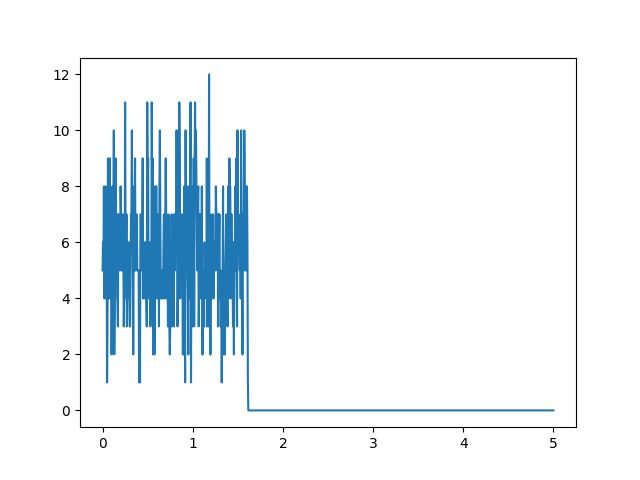

In [ ]:
positions = np.linspace(0,5,1000)
count_arr = []
for pos in positions:
    puck_test = RadioactiveObject("pill","Cs-137",radius=0.01,height=0.01,location=[0,0],num_particles=100)
    puck_vol = puck_test.volume()
    shield_test = ShieldingObject("Lead",length=0.1,width=0.5,height=0.01,location=[0,1])
    vol_test = shield_test.volume()
    parts, part_states, part_angles = particle_gen(shield=shield_test,source=puck_test,resolution=100)
    exit_pos = particle_sim(shield=shield_test,source=puck_test,particles=parts,particle_states=part_states,angles=part_angles)
    detector_test = DetectorObject(length=0.1,width=0.1,height=0.5,location=[0,pos])
    detector_vol = detector_test.volume()
    particle_count = particle_detection(detector_test,exit_pos)
    count_arr.append(particle_count)
    #print(particle_count)

fig,ax = plt.subplots()
ax.plot(positions,count_arr)

In [57]:
source_choice = widgets.Dropdown(options=sources_arr,description='Source',disabled=False)
res_choice = widgets.Dropdown(options=resolution_arr,description='Resolution',disabled=False)
source_loc_choice = widgets.Text(description='Source Location:',value='0,0',disabled=False)
shield_loc_choice = widgets.Text(description='Shield Location:',value='0,0',disabled=False)
detector_loc_choice = widgets.Text(description='Detector Location:',value='0,0',disabled=False)

display(source_choice,res_choice,source_loc_choice,shield_loc_choice,detector_loc_choice)

Dropdown(description='Source', options=(('Tc-99m', 'Tc-99m'), ('Cs-137', 'Cs-137'), ('Ir-192', 'Ir-192')), val…

Dropdown(description='Resolution', options=(('m', 100), ('cm', 1000), ('mm', 10000), ('x10^-1mm', 100000), ('x…

Text(value='0,0', description='Source Location:')

Text(value='0,0', description='Shield Location:')

Text(value='0,0', description='Detector Location:')

In [69]:
def convert_loc(loc):
    inp = loc.value
    out = list(inp.split(","))
    loc_new = [int(i) for i in out]
    return loc_new

rad_source = source_choice.value
resolution = res_choice.value
source_pos = convert_loc(source_loc_choice)
shield_pos = convert_loc(shield_loc_choice)
detector_pos = convert_loc(detector_loc_choice)

In [72]:
def sim_setup(rad,source_pos,shield_pos,detector_pos,resolution=1000):
    puck_test = RadioactiveObject("pill",rad,radius=0.01,height=0.1,location=source_pos,num_particles=1000000)
    puck_vol = puck_test.volume()
    shield_test = ShieldingObject("Tungsten",length=1,width=3,height=0.01,location=shield_pos)
    vol_test = shield_test.volume()
    parts, part_states, part_angles = particle_gen(shield=shield_test,source=puck_test,resolution=resolution)
    exit_pos, parts = particle_sim(shield=shield_test,source=puck_test,particles=parts,particle_states=part_states,angles=part_angles)
    detector_test = DetectorObject(length=0.1,width=0.1,height=0.5,location=detector_pos)
    detector_vol = detector_test.volume()
    return puck_test,shield_test,detector_test,parts

def vis_mat(parts,source,shield,detector,resolution):
    visualisation_matrix = np.zeros((resolution,resolution))
    mid = resolution/2
    fact = resolution/10
    #print(parts[0])
    for part in parts:
        if part[0] < -5:
            part[0] = source.x
            part[1] = source.y
        if part[1] < -5:
            part[0] = source.x
            part[1] = source.y
    source_pos[0] = int((source.x*fact) + mid)
    source_pos[1] = int((source.y*fact) + mid)
    shield_x_one = int((shield.x_one*fact) + mid)
    shield_y_one = int((shield.y_one*fact) + mid)
    shield_x_two = int((shield.x_two*fact) + mid)
    shield_y_two = int((shield.y_two*fact) + mid)
    #print(source_pos)
    parts = (parts*fact) + mid
    #print(parts[0])
    for part in parts:
        #print(part)
        part_x = int(part[0])
        part_y = int(part[1])
        try:
            if shield_x_one < part_x < shield_x_two and shield_y_one < part_y < shield_y_two:
                visualisation_matrix[part_x][part_y] = 0
            #if :
             #   visualisation_matrix[part_x][part_y] = 0
            else:
                visualisation_matrix[part_x][part_y] += 1
        except IndexError:
            pass
    visualisation_matrix[source_pos[0]][source_pos[1]] = np.amax(visualisation_matrix)
    #print(1 in visualisation_matrix)
    return visualisation_matrix

#source_pos = [0,-3]
#shield_pos = [0,1]
#detector_pos = [0,5]
puck_test,shield_test,detector_test,parts = sim_setup(rad_source,source_pos,shield_pos,detector_pos)
visualisation_matrix = vis_mat(parts,puck_test,shield_test,detector_test,resolution)
counts = particle_detection(detector_test,parts)

fig, axes = plt.subplots()
norm = mpl.colors.Normalize(0,(np.amax(visualisation_matrix)/10000))
cmap = 'inferno'
axes.set_axis_off()
heatMap = axes.imshow(visualisation_matrix, cmap=cmap, norm=norm)

print(counts)

IndexError: index 5550 is out of bounds for axis 0 with size 100